# Regresión lineal

En este notebook trabajaremos con datos simulados para estudiar:

- cómo se ajusta una regresión lineal
- cómo se evalúa un modelo de regresión
- cómo cambia el ajuste frente a outliers
- cómo funciona Gradient Descent
- cómo Ridge, Lasso y Elastic Net modifican los coeficientes.


Basado en Machine learning for physics and Astronomy, Viviana Acquaviva (2023)



## Instrucciones

Este notebook combina celdas demostrativas con preguntas de análisis.

No basta con ejecutar el código: deben interpretar los resultados, comparar métricas y justificar sus respuestas usando gráficos, coeficientes y residuos.

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import sklearn
from sklearn import metrics
from sklearn.model_selection import train_test_split, cross_validate, cross_val_predict
from sklearn.model_selection import KFold
from sklearn import linear_model # Nuevo modelo desbloqueado

font = {'size'   : 16}
matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=14) 
matplotlib.rc('ytick', labelsize=14) 
#matplotlib.rcParams.update({'figure.autolayout': False})
matplotlib.rcParams['figure.dpi'] = 300

In [2]:
from sklearn.metrics._scorer import _SCORERS

#### Generamos un dataset de juguete

Primero trabajaremos con datos simulados. La ventaja es que conocemos la relación verdadera:
$$
y_{\rm true} = 3x + 3
$$

Luego agregamos ruido para simular mediciones imperfectas.

In [3]:
np.random.seed(16) #fijar semilla para la reproducibilidad

x = np.arange(100) 

yp = 3*x + 3 + 2*(np.random.poisson(3*x+3,100)-(3*x+3)) 
#genera datos con dispersión, siguiendo una distribución Poissoniana
# con valor esperado = y (modelo lineal), centrado alrededor de cero

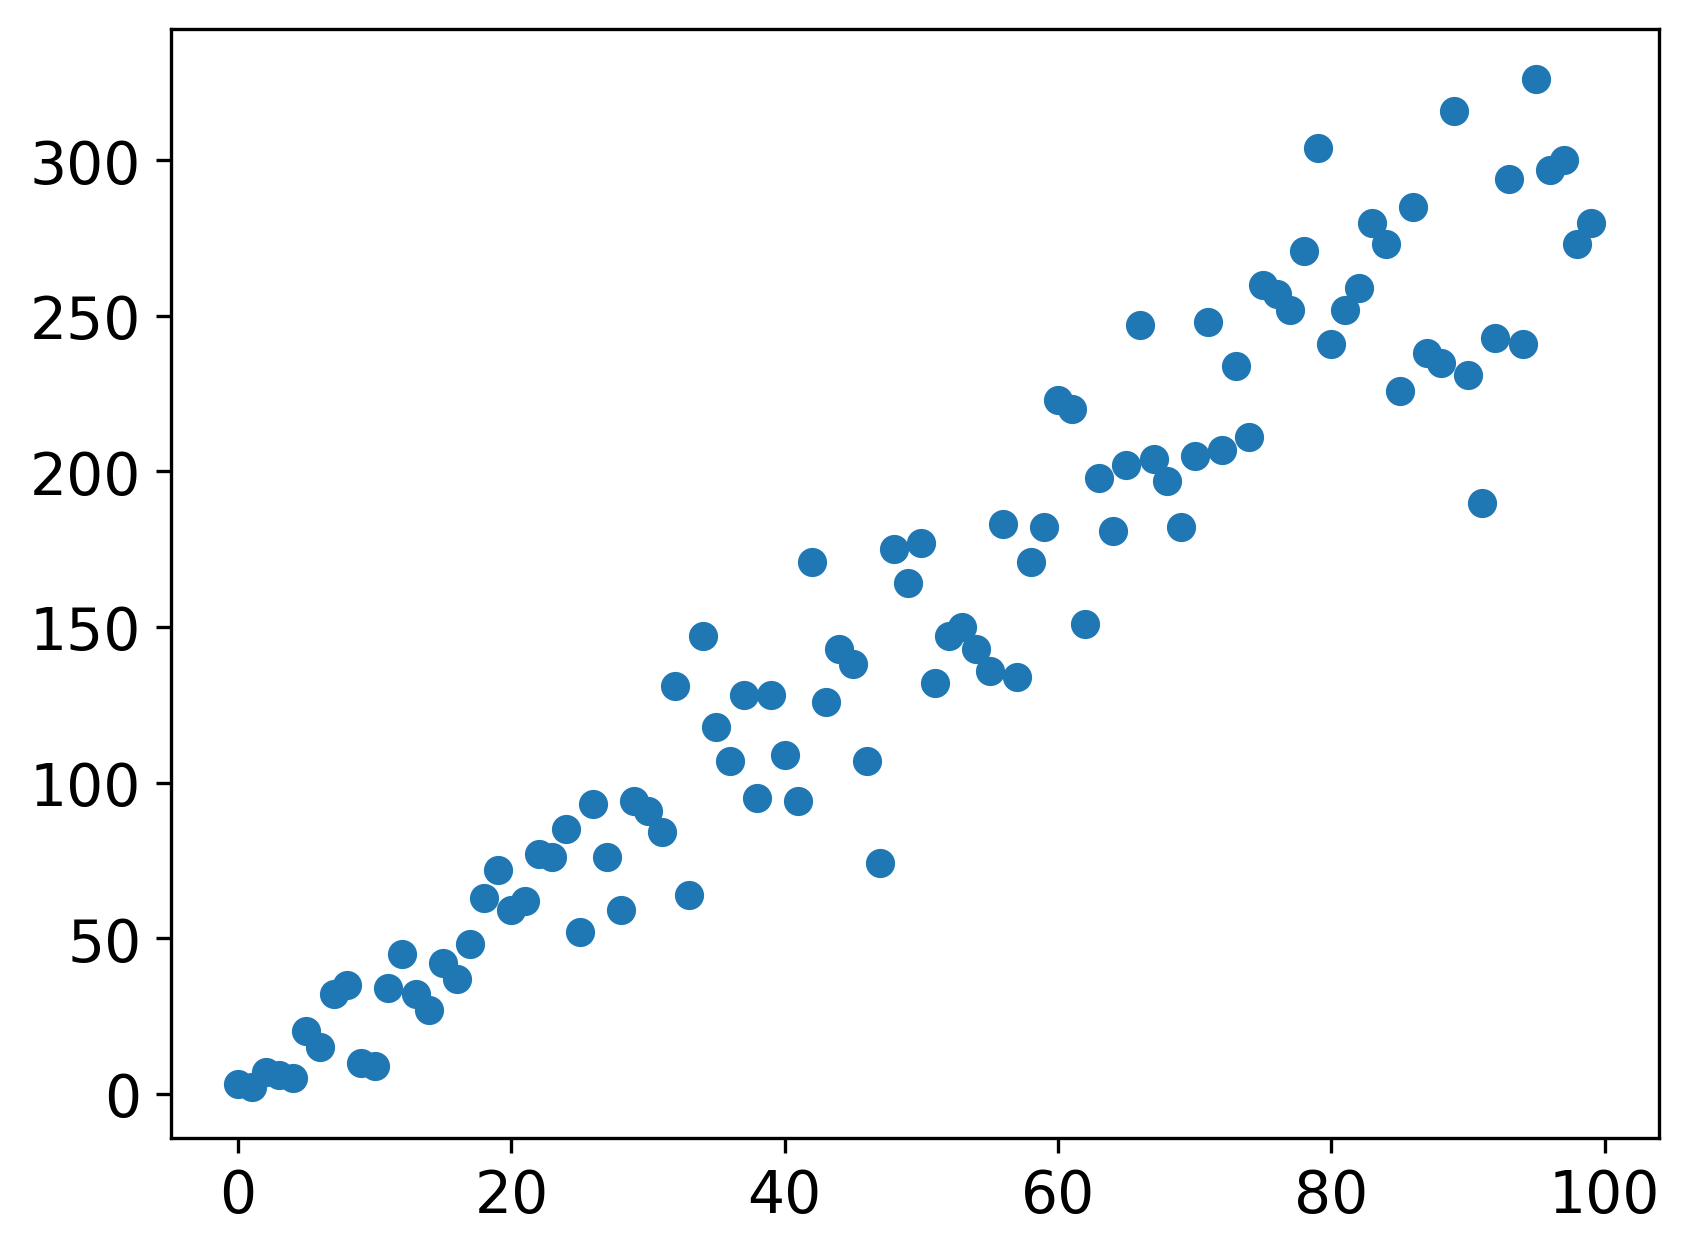

In [4]:
plt.scatter(x, yp);

### Pregunta 

De acuerdo al gráfico anterior:
- ¿Los datos siguen una tendencia aproximadamente lineal?
- ¿La dispersión alrededor de la recta parece constante para todos los valores de \(x\)?
- ¿Qué podría implicar esto al mirar residuos más adelante?

- Pareciera ser que los datos siguen una tendencia lineal
- La dispersión alrededor de la recta parace ser mayor para mayores valores de x, con valores cada vez más diversos de \(y\) a medida que \(x\) aumenta.
- Considerando la tendencia de los datos a dispersarse, es de esperar que aumenten los residuos más adelante, entregando métricas de erros más altas.

In [5]:
model = linear_model.LinearRegression()

#### Ajuste con regresión lineal

Ajustaremos un modelo de la forma:

$$
\hat{y} = \beta_0 + \beta_1 x
$$

En `sklearn`, cuando tenemos una sola feature, necesitamos escribir `x` como una matriz de forma `(n_samples, 1)`. Por eso usamos:

```python
x.reshape(-1, 1)

In [8]:
model.fit(x.reshape(-1, 1), yp)

LinearRegression()

In [9]:
slope = model.coef_[0]
intercept = model.intercept_

print(f"Intercepto beta_0 = {intercept:.3f}")
print(f"Pendiente beta_1 = {slope:.3f}")

Intercepto beta_0 = -0.126
Pendiente beta_1 = 3.025


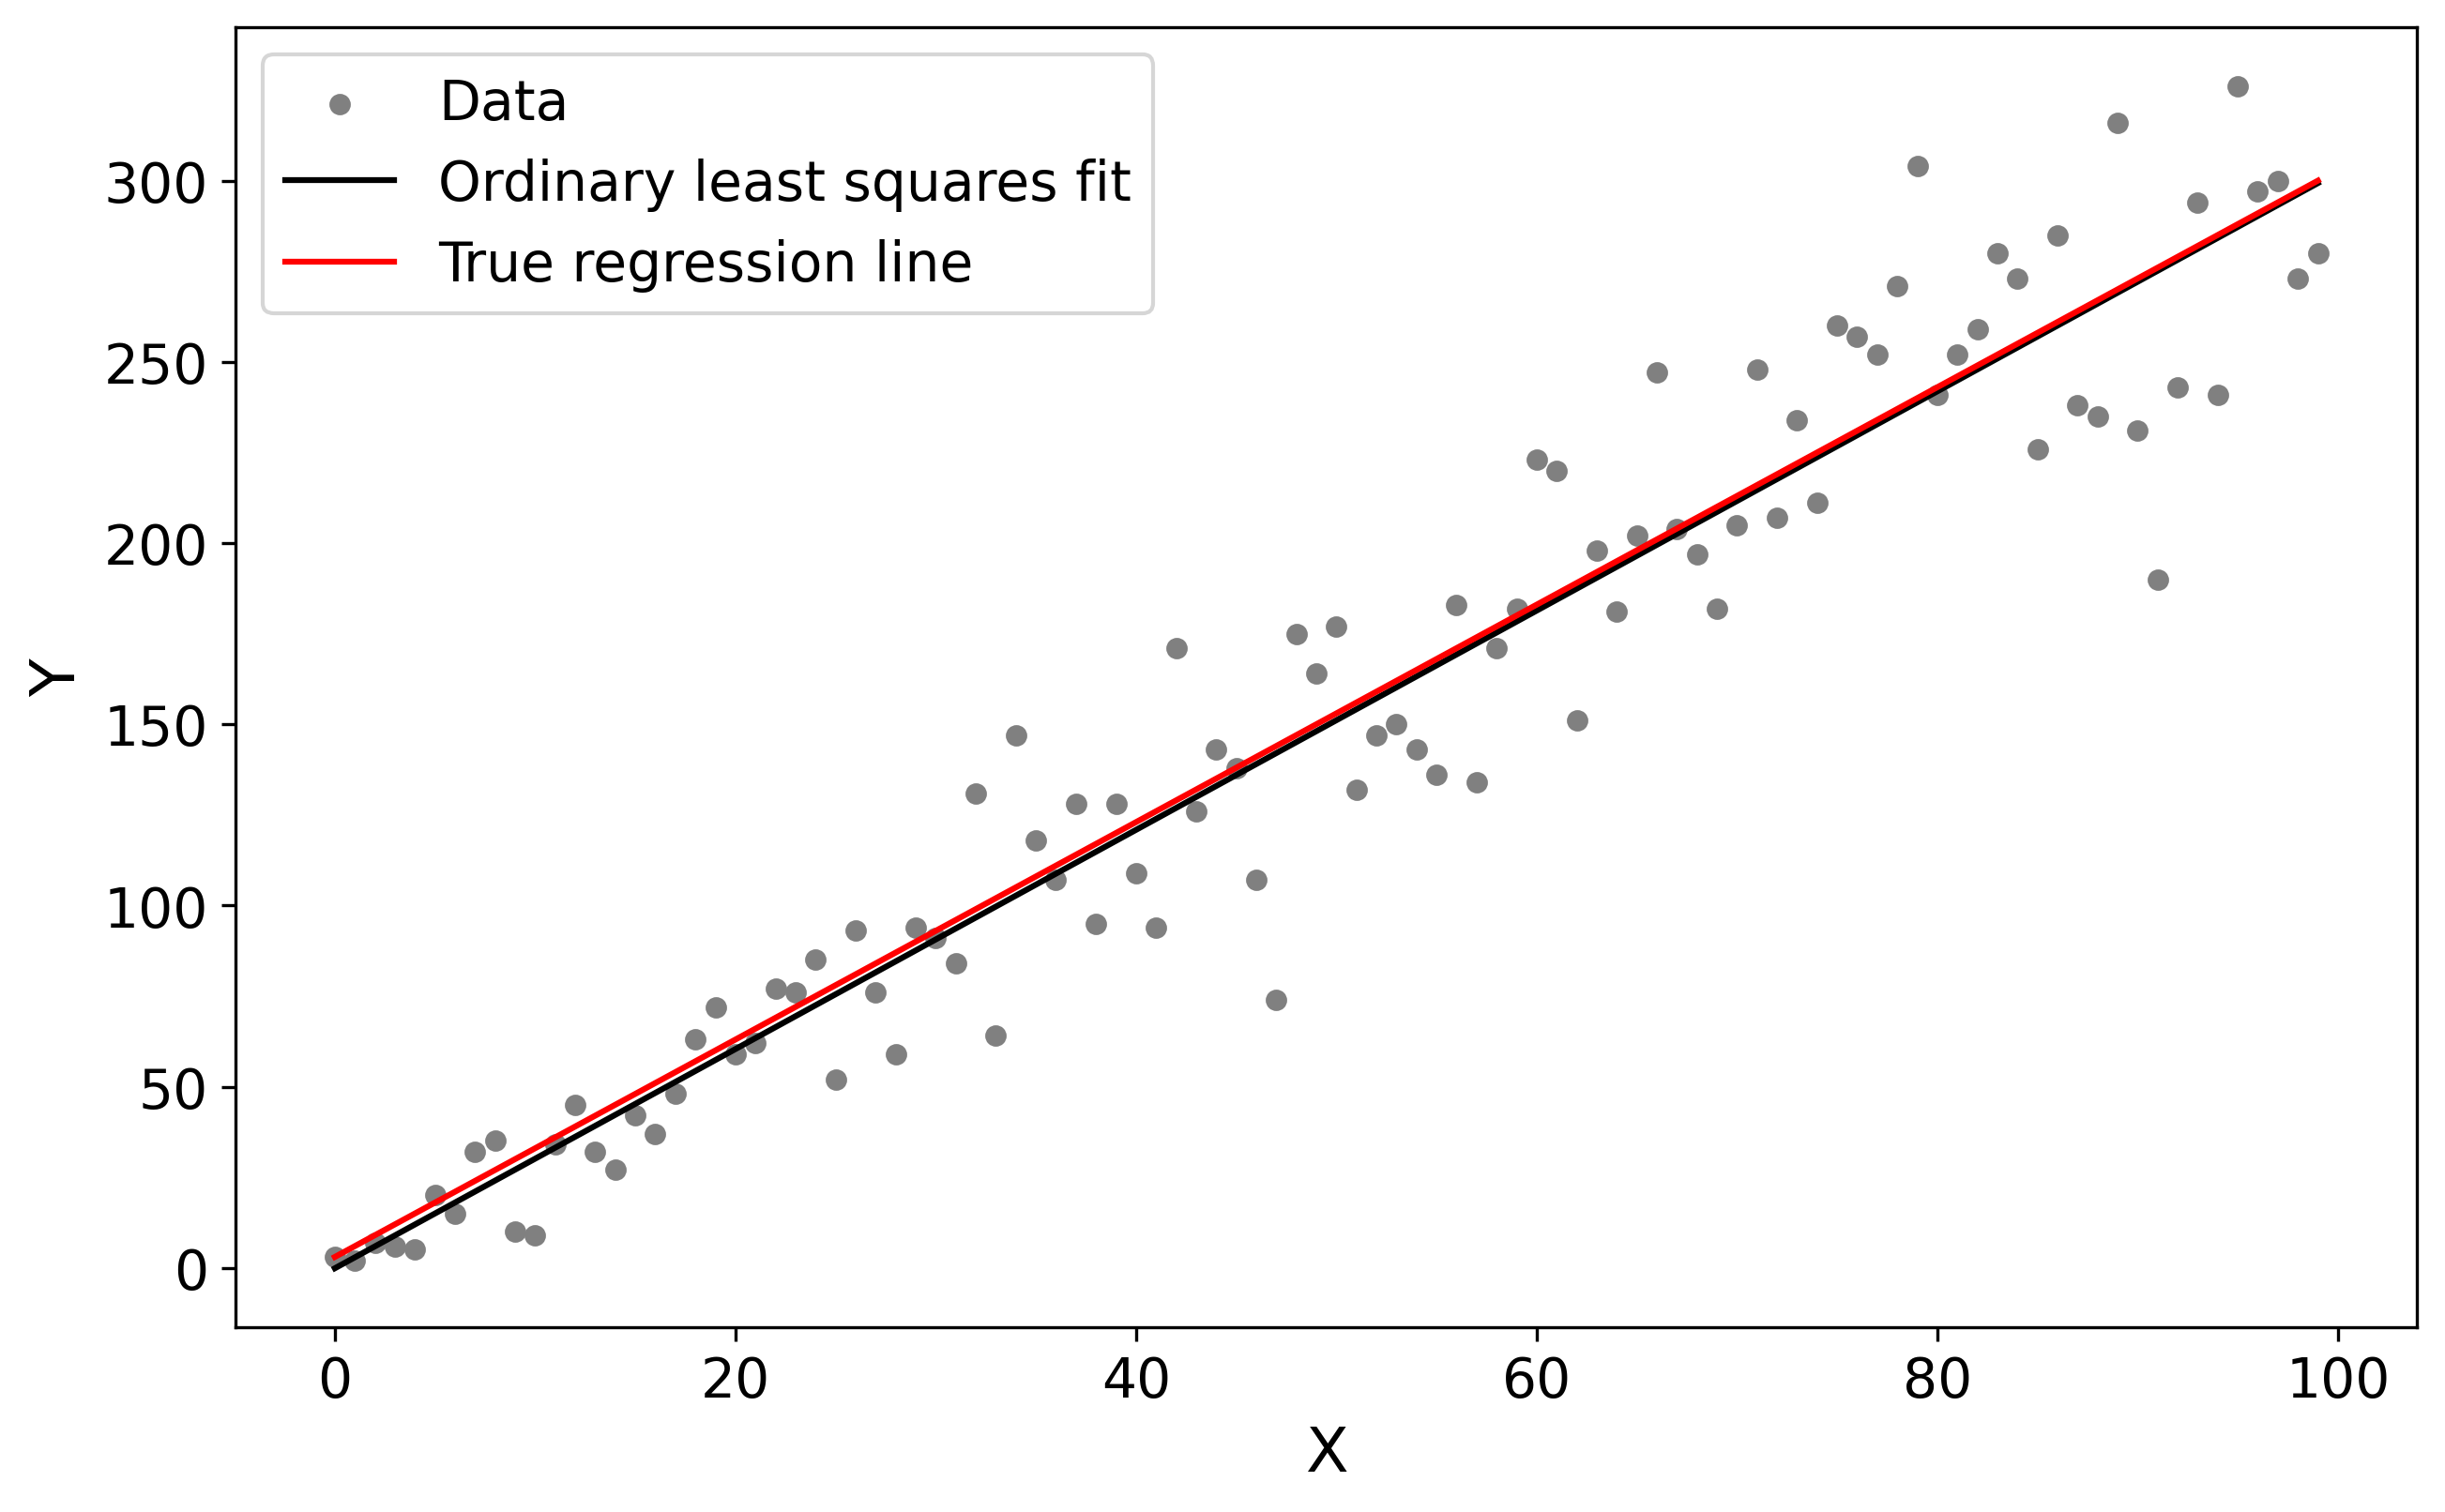

In [10]:
plt.figure(figsize = (10,6))
plt.scatter(x,yp, s = 20, c = 'gray', label = 'Data')
plt.plot(x, slope*x + intercept, c ='k', label = 'Ordinary least squares fit')
plt.plot(x, 3*x + 3, c = 'r', label = 'True regression line')
plt.legend(fontsize = 14)
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

### Pregunta

Compara los coeficientes ajustados con los valores verdaderos $\beta_0=3$ y $\beta_1=3$
-  ¿Son exactamente iguales? ¿Por qué?
-  ¿Qué representa físicamente/matemáticamente la pendiente en este modelo?

- Mientras que el valor de $\beta_1$ se acerca bastante al real (diferencia de alrededor de 1%), la diferencia con $\beta_0$ es clara. Esto puede explicarse por la dispersión de los datos; $\beta_1$ es el coeficiente que determina la pendiente de la recta, mientras que $\beta_0$ indica su distancia del cero. Es posible que el modelo se "confunda" en este aspecto dado el ruido agregado a los datos.
- Como no sabemos si hay un problema físico detrás de estos datos simulados, sólo se puede inferir con respecto a las posibles interpretaciones físicas. Si estos son, por ejemplo, datos de tiempo y posición de un cuerpo, la pendiente representaría la velocidad (constante) de dicho cuerpo. Matemáticamente hablando, una pendienta representa la inclinación de una recta.

#### Solución analítica de mínimos cuadrados

Para regresión lineal simple, la pendiente que minimiza el MSE puede escribirse como:

$$
\beta_1 =
\frac{\sum_i (x_i-\bar{x})(y_i-\bar{y})}
{\sum_i (x_i-\bar{x})^2}
$$

y luego:

$$
\beta_0 = \bar{y} - \beta_1\bar{x}
$$

**Implemente en el código para calcular a partir de la solución analítica los coeficientes y compare**

In [183]:
# cálculo del denominador y el nominador de beta_1
x_mean = np.mean(x)
yp_mean = np.mean(yp)

numerator = np.sum((x - x_mean) * (yp - yp_mean))
denominator = np.sum((x - x_mean) ** 2)

In [185]:
beta1 = numerator/denominator
beta0 = np.mean(yp) - beta1*np.mean(x)

print(f"Beta_0 analítico = {beta0:.3f}")
print(f"Beta_1 analítico = {beta1:.3f}")

Beta_0 analítico = -0.126
Beta_1 analítico = 3.025


Es posible ver que el cálculo analítico arroja exactamente los mismos valores que LinearRegression.  

#### Evaluación del modelo: validación cruzada y métricas

Ahora aplicamos una idea que ya usamos en clasificación: validar el modelo en distintos subconjuntos de datos.

Por defecto, `LinearRegression.score()` devuelve \(R^2\), no accuracy.

Podemos ver todos los scorers implementados en sklearn

In [26]:
from sklearn.metrics import get_scorer_names
print(get_scorer_names())

['accuracy', 'adjusted_mutual_info_score', 'adjusted_rand_score', 'average_precision', 'balanced_accuracy', 'completeness_score', 'd2_absolute_error_score', 'explained_variance', 'f1', 'f1_macro', 'f1_micro', 'f1_samples', 'f1_weighted', 'fowlkes_mallows_score', 'homogeneity_score', 'jaccard', 'jaccard_macro', 'jaccard_micro', 'jaccard_samples', 'jaccard_weighted', 'matthews_corrcoef', 'mutual_info_score', 'neg_brier_score', 'neg_log_loss', 'neg_max_error', 'neg_mean_absolute_error', 'neg_mean_absolute_percentage_error', 'neg_mean_gamma_deviance', 'neg_mean_poisson_deviance', 'neg_mean_squared_error', 'neg_mean_squared_log_error', 'neg_median_absolute_error', 'neg_negative_likelihood_ratio', 'neg_root_mean_squared_error', 'neg_root_mean_squared_log_error', 'normalized_mutual_info_score', 'positive_likelihood_ratio', 'precision', 'precision_macro', 'precision_micro', 'precision_samples', 'precision_weighted', 'r2', 'rand_score', 'recall', 'recall_macro', 'recall_micro', 'recall_samples'

#### Implemente una validación cruzada con Kfold

y encuentre los resultados para las métricas R^2, 'neg_mean_absolute_error'  (MAE) y 'neg_mean_squared_error' (MSE)

Para los estimadores de la performance del modelo del tipo "error" siempre queremos que sean pequeños (menor error, mejor modelo). Pero en sklearn, reciben un signo negativo, como neg_mean_squared_error, para mantener la consistencia de "alto puntaje=mejor" de los scorers

In [62]:
# implementando validación cruzada

cv = KFold(shuffle = True, n_splits = 5, random_state=5)
scores_r2 = cross_validate(model, x.reshape(-1, 1), yp, cv = cv, return_train_score = True)

print(f"R2 test : {scores_r2['test_score'].mean():.3f} ± {scores_r2['test_score'].std():.3f}")
print(f"R2 train: {scores_r2['train_score'].mean():.3f} ± {scores_r2['train_score'].std():.3f}")

R2 test : 0.911 ± 0.023
R2 train: 0.925 ± 0.005


In [61]:
scores_mse = cross_validate(model, x.reshape(-1, 1), yp, cv = cv, scoring = 'neg_mean_squared_error')

scores_mae = cross_validate(model, x.reshape(-1, 1), yp, cv = cv, scoring = 'neg_mean_absolute_error')

print(f"MSE test: {-scores_mse['test_score'].mean():.3f}")
print(f"MAE test: {-scores_mae['test_score'].mean():.3f}")

MSE test: 659.430
MAE test: 19.437


**Haga un gráfico de los residuos $r_i=y_i-\hat{y}_i$**

In [65]:
residuos = []
for i in range(len(x)):
    r_i = yp[i] - np.mean(yp)

    residuos.append(r_i)

residuos = np.array(residuos)

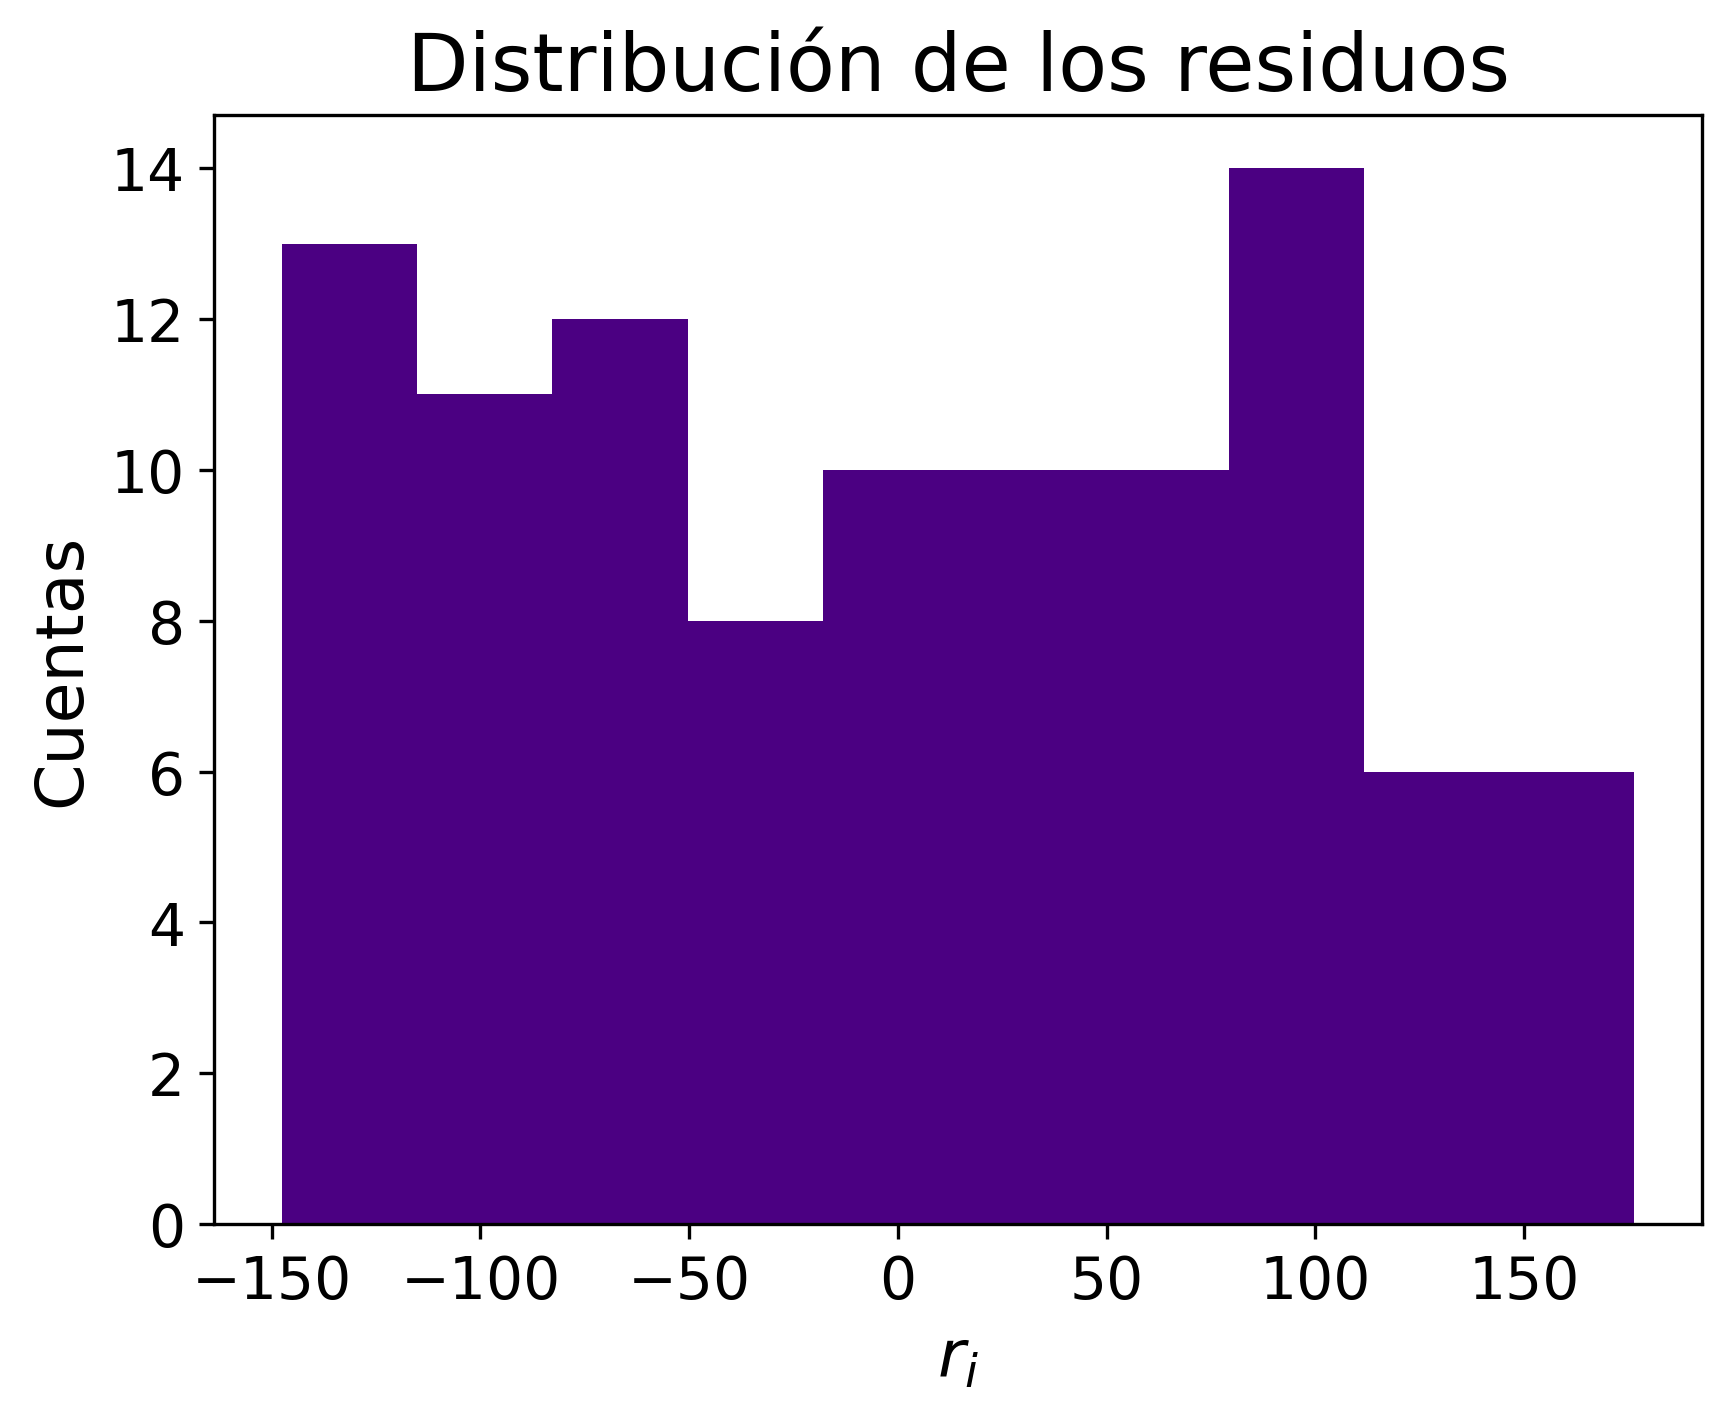

In [71]:
plt.hist(residuos, color = 'indigo')
plt.title("Distribución de los residuos")
plt.xlabel(r"$r_i$")
plt.ylabel("Cuentas")
plt.show()

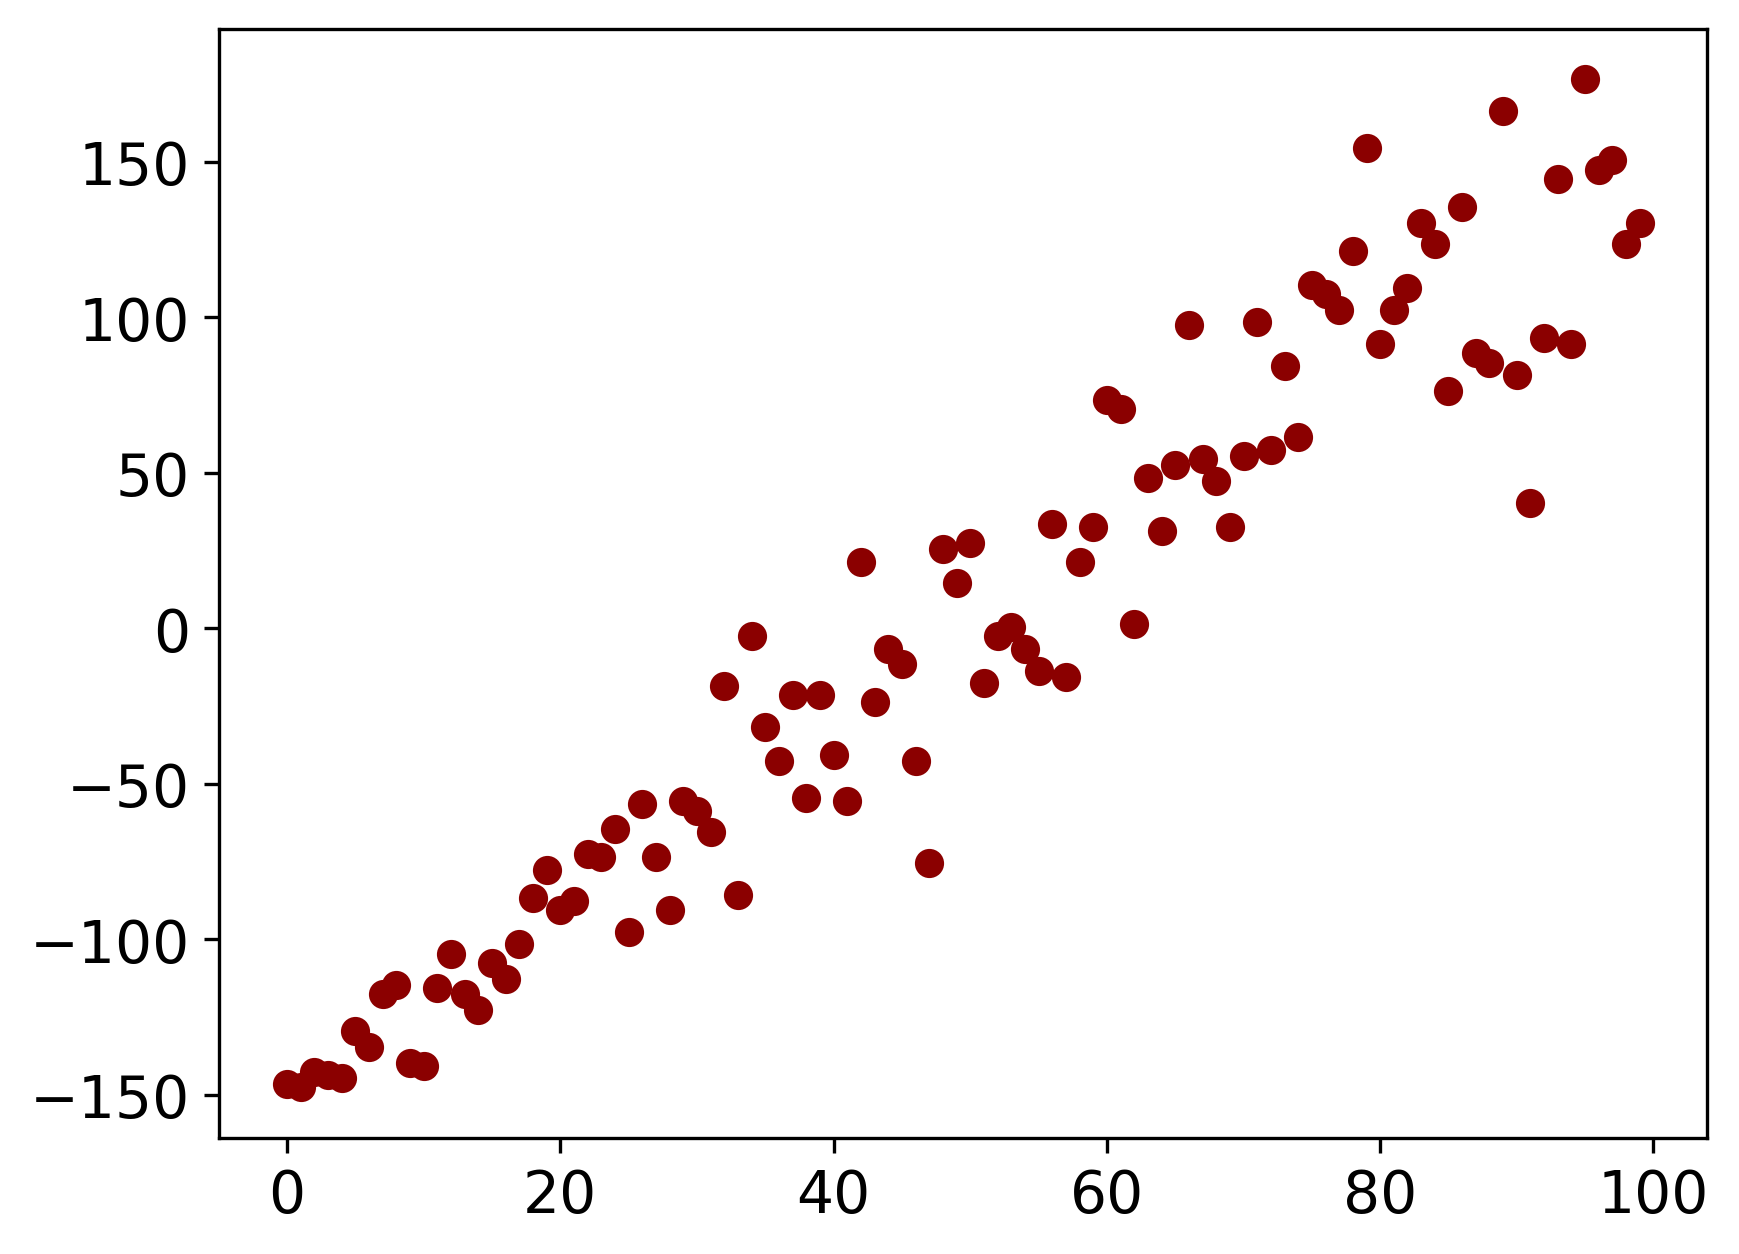

In [72]:
plt.scatter(x, residuos, color = 'darkred')
plt.show()

#### Pregunta 
-  ¿Los residuos parecen distribuidos aleatoriamente alrededor de cero?
-  ¿La dispersión de los residuos cambia con $x$?
-  ¿Qué nos dice esto sobre el modelo y/o sobre cómo fueron generados los datos?

- Observando el gráfico, se aprecia que los residuos no muestran una distribución uniforme alrededor del cero. Parece haber una distribución aleatoria, con una baja en la cantidad de residuos mayores a 100.
- Tal como ocurre con $y$, es posible ver que la dispersión de los residuos se vuelve mayor a medida que aumenta el valor de $x$.
- Podemos intuir que existe una dependencia directa entre el valor de $x$ y la dispersión en los datos. De esta forma, es de esperar que esta dispersión afecte a un modelo de regresión lineal y lo haga disminuir su calidad. Si estuviéramos evaluando un problema físico, sería un problema importante saber qué rango de la variable independiente tenemos y cómo esto afecta nuestros modelos (por ejemplo, en un modelo cosmológico, el tiempo desde el big bang).

### ¿Qué ocurre si agregamos outliers?

In [27]:
np.random.seed(12) # fijada la semilla
out = np.random.choice(100,15) #seleccionamos 15 índices de outliers
yp_wo = np.copy(yp)
np.random.seed(12) #fijada 
yp_wo[out] = yp_wo[out] + 5*np.random.rand(15)*yp[out]

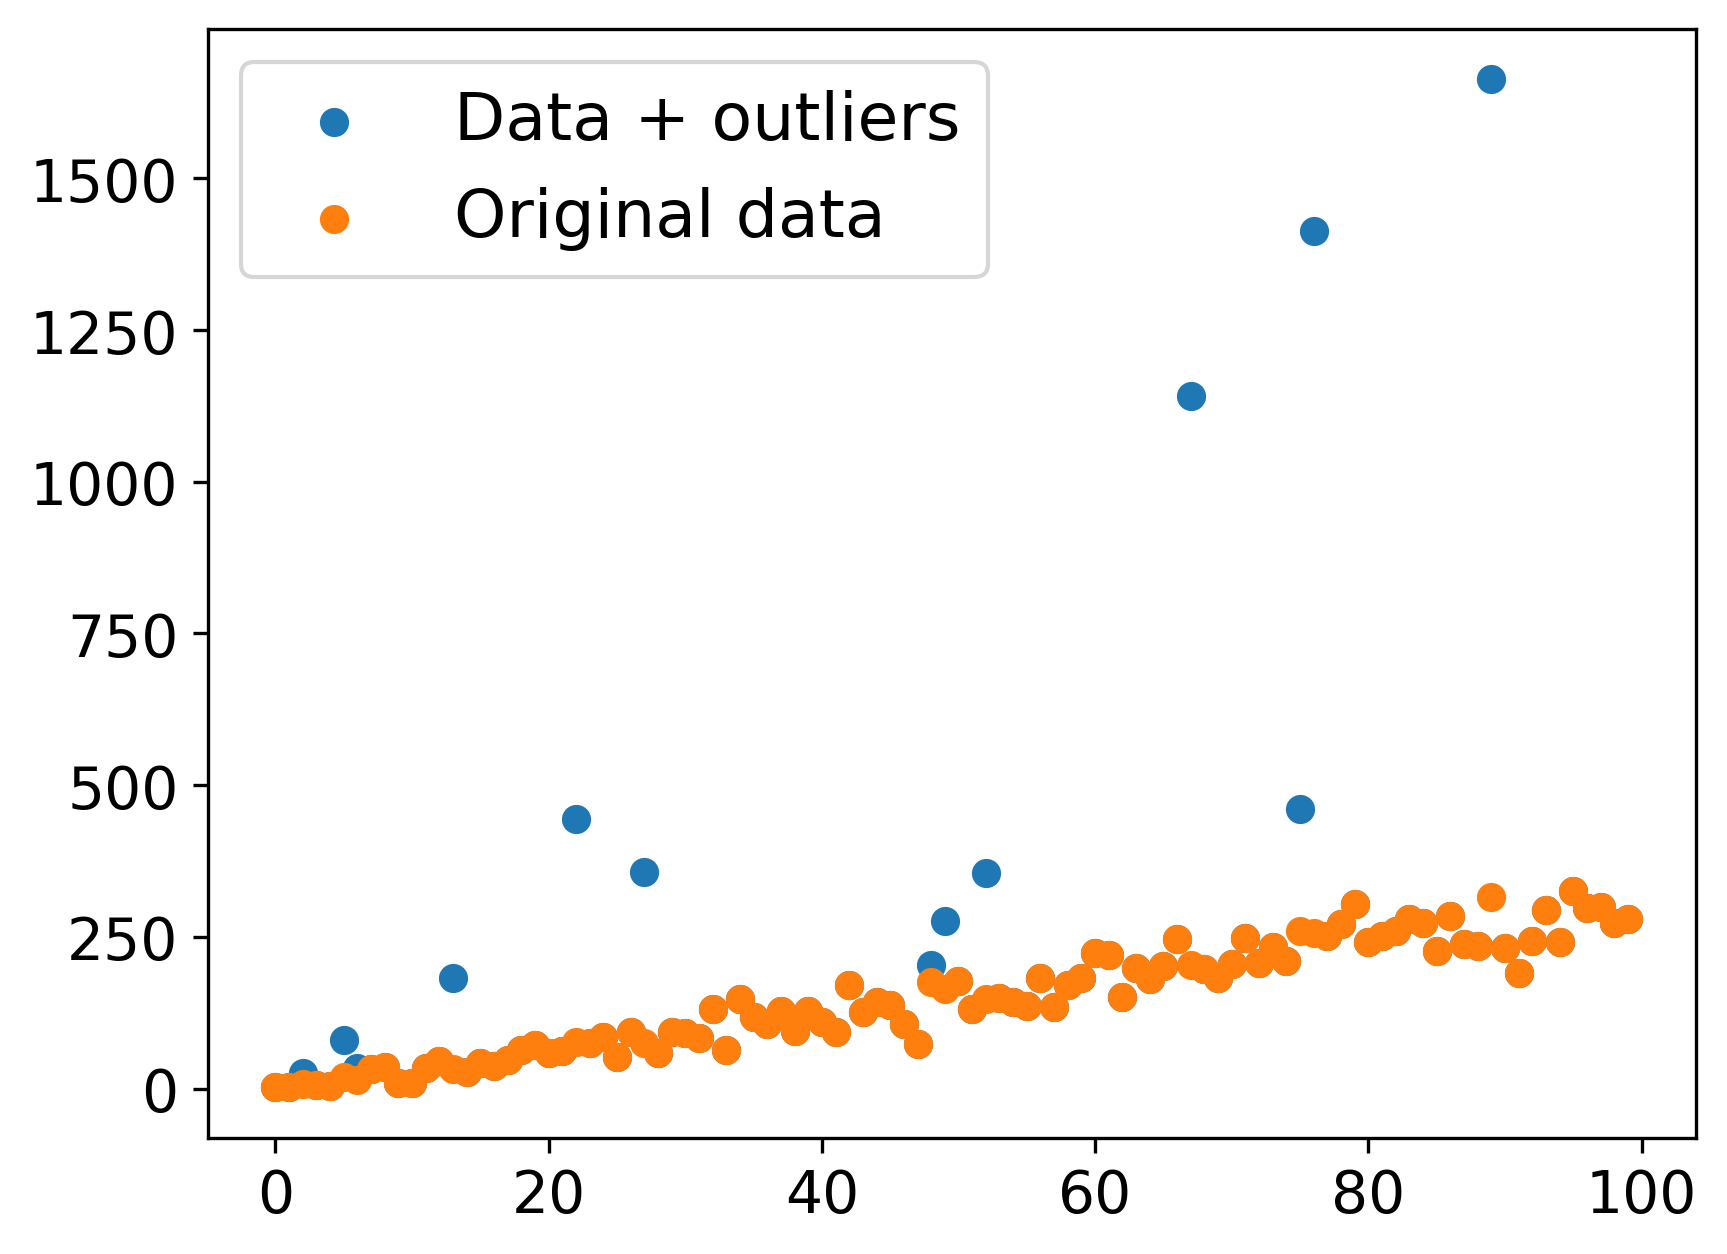

In [28]:
plt.scatter(x,yp_wo, label = 'Data + outliers')
plt.scatter(x,yp, label = 'Original data')
plt.legend();

#### Ajuste el modelo de regresión lineal para los datos con outliers

Responda: 
- Compare visualmente el ajuste antes y después de agregar outliers. ¿La recta cambia mucho? ¿Hacia dónde se mueve?
- Compara los coeficientes $\beta_0$ y $\beta_1$ del modelo con y sin outliers.  ¿Cuál cambia más: el intercepto o la pendiente?
- Compara las métricas MAE, MSE, RMSE y $R^2$ antes y después de agregar outliers. ¿Qué métrica se ve más afectada?
- ¿Por qué el MSE/RMSE suele ser más sensible a outliers que el MAE?
- ¿Todos los outliers afectan de la misma manera al modelo? Observa si los puntos atípicos están lejos en $y$, lejos en $x$, o en ambos.
- ¿Dirías que el modelo con outliers está aprendiendo la tendencia general de los datos o está siendo “tirado” por algunos puntos extremos? Justifica.
- Si este fuera un dataset real, ¿eliminarías los outliers automáticamente? Explica qué revisarías antes de decidir.

In [37]:
# implementando el modelo
model_outliers = linear_model.LinearRegression() 
model_outliers.fit(x.reshape(-1, 1), yp_wo)

LinearRegression()

In [145]:
# cálculo de coeficientes

slope_wo = model_outliers.coef_[0]
intercept_wo = model_outliers.intercept_

print(f"Intercepto beta_0 (con outliers) = {intercept_wo:.3f}")
print(f"Pendiente beta_1 (con outliers) = {slope_wo:.3f}")

Intercepto beta_0 (con outliers) = 1.548
Pendiente beta_1 (con outliers) = 3.978


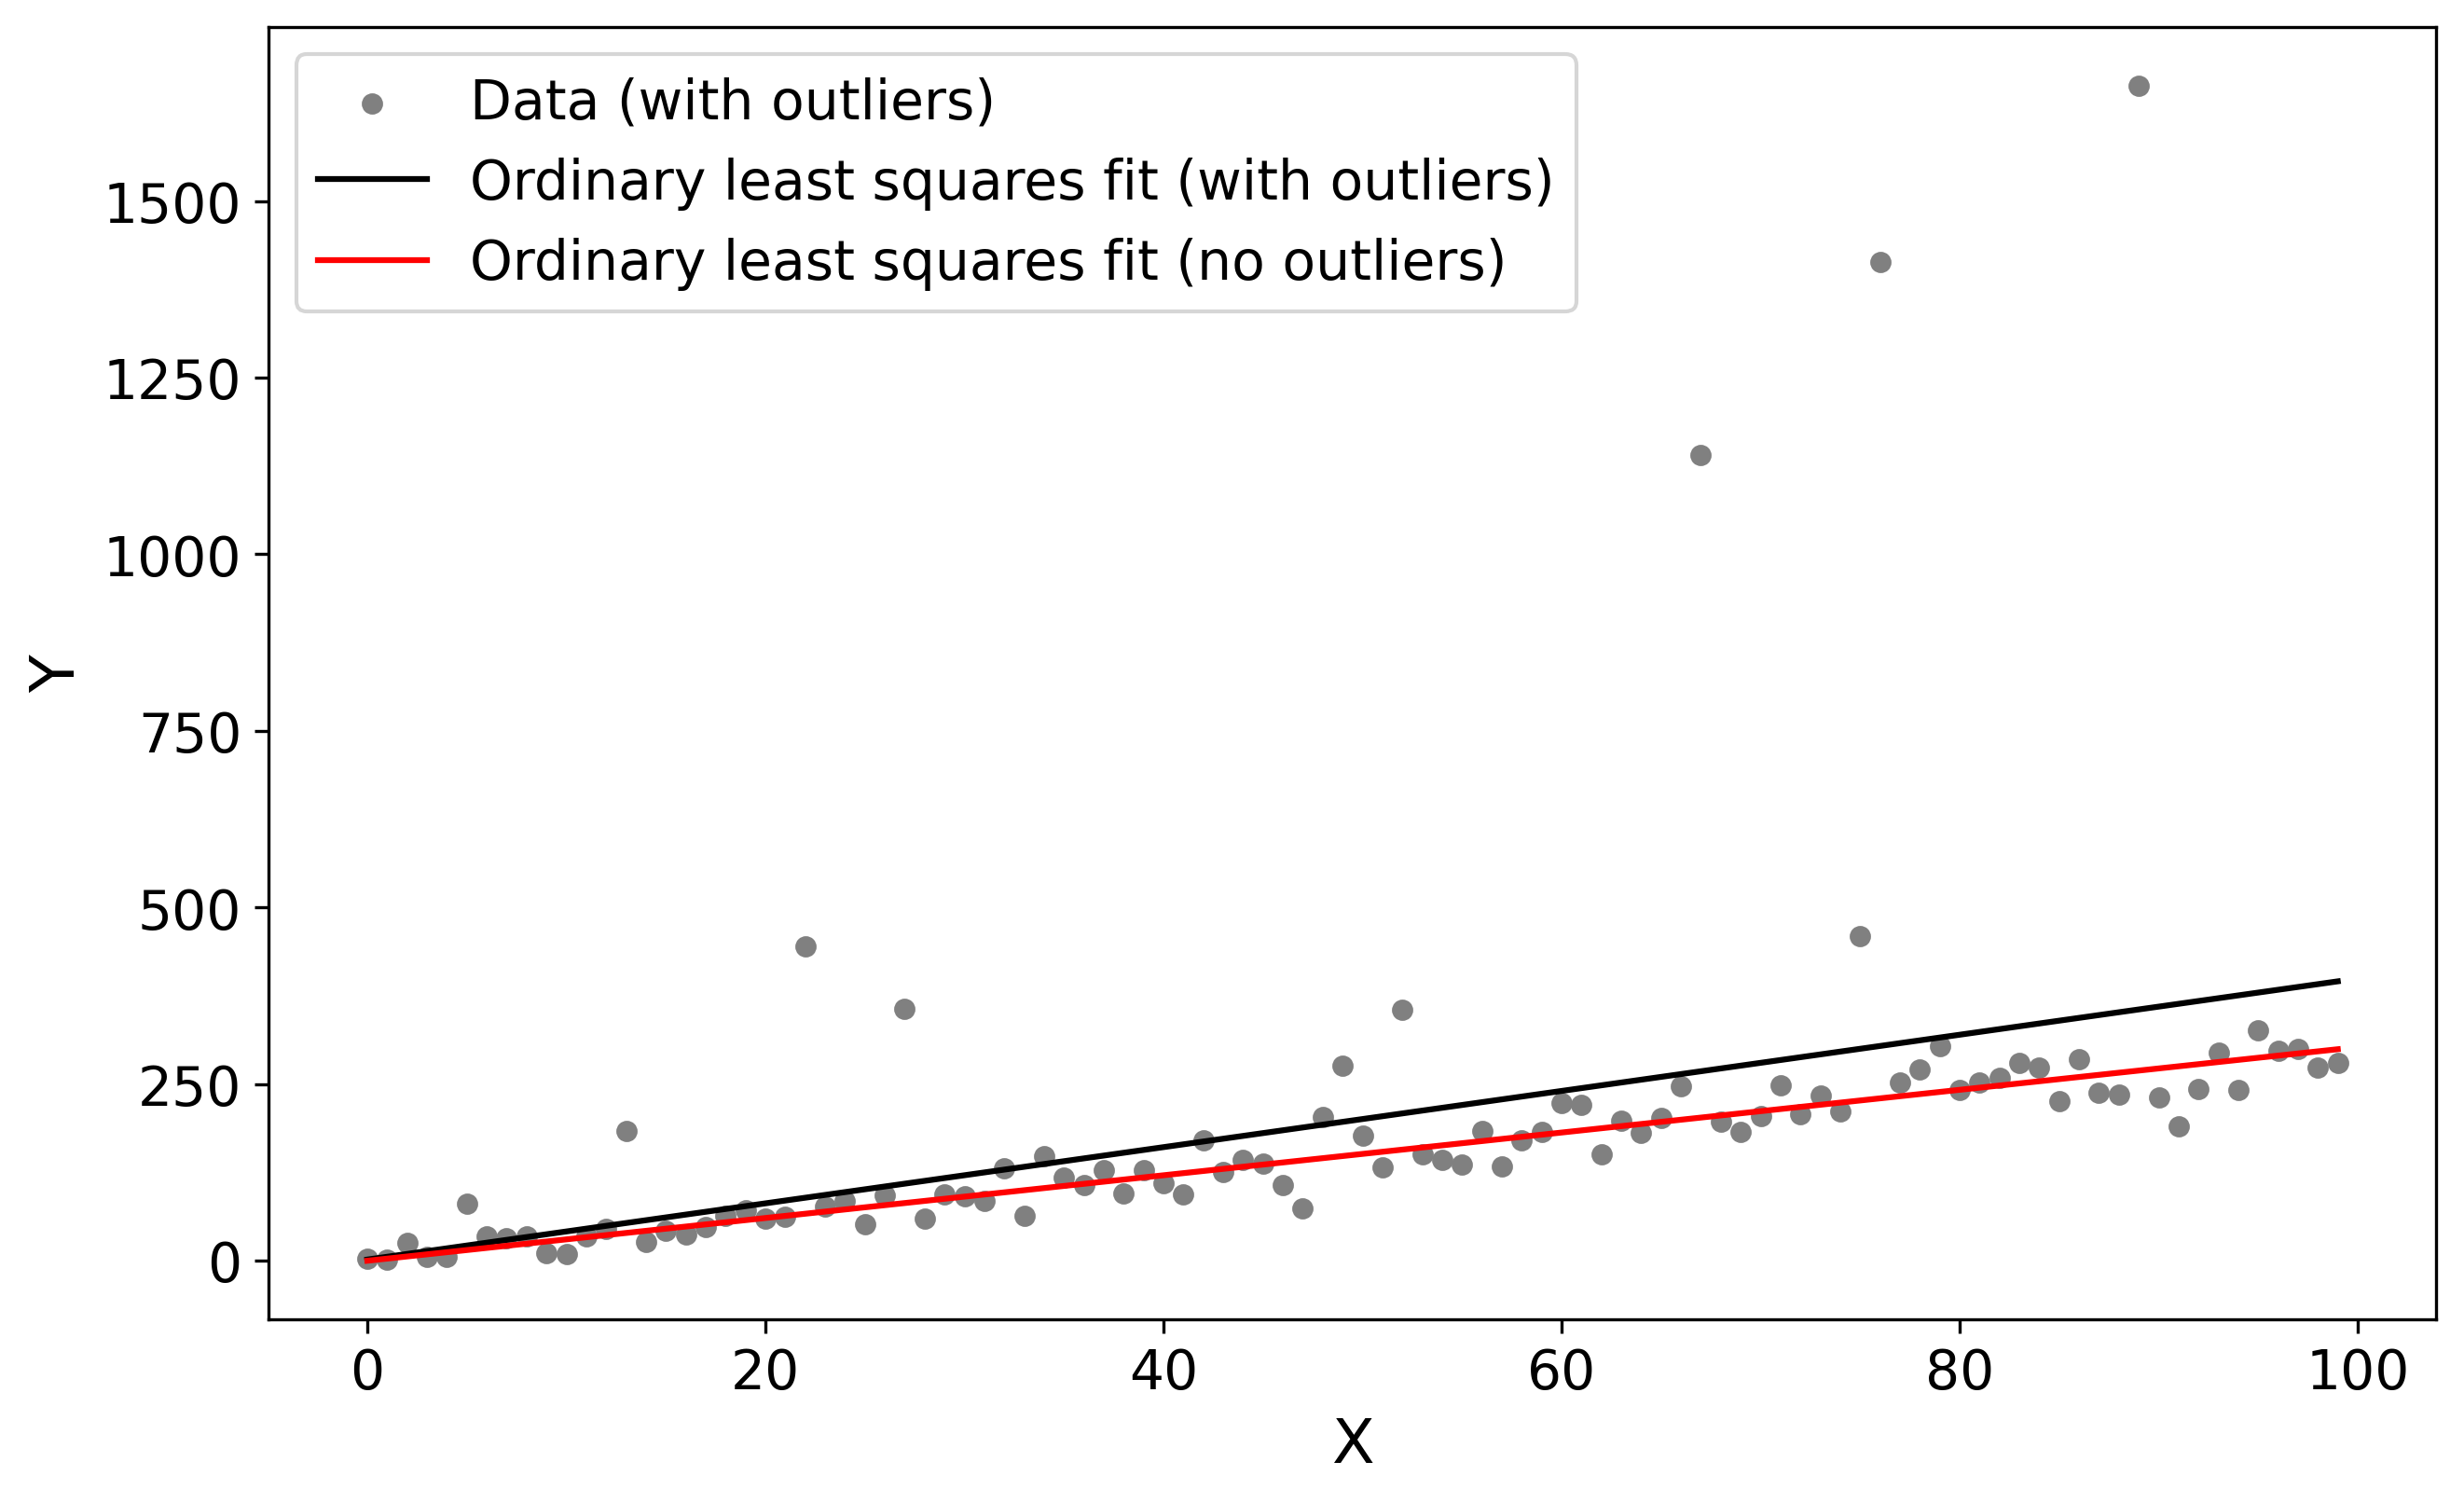

In [146]:
plt.figure(figsize = (10,6))
plt.scatter(x,yp_wo, s = 20, c = 'gray', label = 'Data (with outliers)')
plt.plot(x, slope_wo*x + intercept_wo, c ='k', label = 'Ordinary least squares fit (with outliers)')
plt.plot(x, slope*x + intercept, c ='red', label = 'Ordinary least squares fit (no outliers)')
#plt.plot(x, 3*x + 3, c = 'r', label = 'True regression line')
plt.legend(fontsize = 14)
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

In [147]:
r2_wo = cross_validate(model_outliers, x.reshape(-1, 1), yp_wo, cv = cv, return_train_score = True)
mse_wo = cross_validate(model_outliers, x.reshape(-1, 1), yp_wo, cv = cv, scoring = 'neg_mean_squared_error')
mae_wo = cross_validate(model_outliers, x.reshape(-1, 1), yp_wo, cv = cv, scoring = 'neg_mean_absolute_error')

In [148]:
print(f"R2 test : {r2_wo['test_score'].mean():.3f} ± {r2_wo['test_score'].std():.3f}")
print(f"R2 train: {r2_wo['train_score'].mean():.3f} ± {r2_wo['train_score'].std():.3f}")
print(f"MSE test: {-mse_wo['test_score'].mean():.3f}")
print(f"MAE test: {-mae_wo['test_score'].mean():.3f}")

R2 test : 0.050 ± 0.351
R2 train: 0.240 ± 0.025
MSE test: 46183.769
MAE test: 92.960


In [150]:
# cálculo de diferencias porcentuales para saber cuál fue la métrica más afectada
print(f"Diferencia R2 (test score): {((scores_r2["test_score"].mean()-r2_wo["test_score"].mean())/scores_r2["test_score"].mean())*100:.3f}%")

print(f"Diferencia R2 (train score): {((scores_r2["train_score"].mean()-r2_wo["train_score"].mean())/scores_r2["train_score"].mean())*100:.3f}%")

print(f"Diferencia MSE: {((scores_mse['test_score'].mean()-mse_wo['test_score'].mean())/-scores_mse['test_score'].mean())*100:.3f}%")

print(f"Diferencia MAE: {((scores_mae['test_score'].mean()-mae_wo['test_score'].mean())/-scores_mae['test_score'].mean())*100:.3f}%")

Diferencia R2 (test score): 94.514%
Diferencia R2 (train score): 74.047%
Diferencia MSE: 6903.585%
Diferencia MAE: 378.256%


Responda: 
- Puede apreciarse un cambio significativo en la recta, que se mueve hacia arriba, debido a que considera a los outliers.
- El intercepto $\beta_0$ es el que presenta la mayor diferencia en comparación con el calculado anteriormente. También hay un importante cambio en $\beta_1$, cuyo valor aumenta en más del 10% del calculado sin outliers.
- De todas las métricas calculadas, la que se ve más afectada es el MSE, seguido por el MAE.
- El MSE/RMSE es más sensible a outliers debido a que el error (la distancia al valor real) es elevado al cuadrado en la ecuación que determina su valor, de manera que un error más grande pesa más en el MSE que en el MAE.
- Todos los valores de $x$ de los outliers se encuentran dentro del mismo rango que los datos originales. Es en el eje $y$ que existe una distancia mayor entre los outliers y los datos originales que aumenta significativamente el rango de $y$, alterando por lo tanto el fit que hace el modelo.
- Considerando lo anterior, diría que el modelo está siendo altamente afectado por los outliers; su gran distancia con el resto de los datos hacen que el modelo cambie y su eficacia al poder hacer regresiones con datos de esta naturaleza cambia.
- No podría eliminar los outliers sin antes hacer una revisión de los datos. Si se tratan de datos de una situación física, por ejemplo, revisaría las posibles causas de presencia de outliers para determinar si es bueno/válido eliminar los outliers o no.

Del resultado del modelo lineal para estos datos con outliers, guarde los coeficientes encontrados en un array llamado `theta_ne`

In [151]:
theta_ne = np.array([[intercept_wo], [slope_wo]])

Esto es la solución usando el modelo y la **ecuación normal**

### Ahora implementaremos 3 métodos de gradient descent: batch, estocástico y mini-batch

En esta sección ajustamos una regresión lineal usando Gradient Descent en vez de usar directamente `LinearRegression`. Compararemos con los resultados encontrados en la regresión con outliers.




Agregaremos $x_0=1$ a cada instancia, este es el término de bias ($\beta_0$) y se usa para escribir la solución en la forma de multiplicación de matrices 

$y=X\cdot \theta$

donde $\theta$ es el vector de coeficientes que incluye el término $\beta_0$  (término de bias) y $\beta_1, \beta_2, \beta_3,..., \beta_n$

In [152]:
X = np.c_[np.ones((100, 1)), x]  

print(X.shape) #la forma es el número de instancias x número de parámetros


(100, 2)


Podemos calcular la pérdida asociada con la ecuación normal, usando la expresión 

$\text{MSE} = \frac{1}{m}\|X\cdot \theta - y \|^2$

In [153]:
loss_ne = np.mean((X.dot(theta_ne) - yp_wo.reshape(-1,1))**2)

### Batch GD

In [154]:
np.random.seed(10) 

eta = 0.0001 #learning step (valor pequeño asegura convergencia, aunque lenta)
n_iterations = 1000 #puede cambiar este valor!!
m = 100 #número de instancias

theta_path_bgd = [] #arreglo para guardar los valores de los parámetros en cada iteración

theta = np.random.randn(2,1) #inicializamos con valores aleatorios

for iteration in range(n_iterations):
    gradients = 2/m * X.T.dot(X.dot(theta) - yp_wo.reshape(-1,1)) #gradiente de la función de pérdida respecto a theta
    theta = theta - eta * gradients #actualiza los valores de theta, en cada cálculo del gradiente, en cada paso
    theta_path_bgd.append(theta) #

theta_path_bgd = np.array(theta_path_bgd) #guardamos esos valores (útil para una visualización)

theta_bgd = theta #resultado final

In [155]:
theta_bgd

array([[1.38909891],
       [3.98081931]])

In [156]:
loss_bgd = np.sum(1/m*(X.dot(theta_bgd) - yp_wo.reshape(-1,1))**2)

In [157]:
loss_bgd

np.float64(43259.08804185896)

In [158]:
(loss_ne-loss_bgd)/loss_ne*100 #diferencia porcentual con la ecuación normal

np.float64(-1.4834194931614274e-05)

###  GD estocástico

In [159]:
np.random.seed(10) #

theta = np.random.randn(2,1)  #inicializa los parámetros

eta = 0.000005 #learning step, valor más pequeño evita saltos muy grandes

n_iterations = 10000 #necesitamos más iteraciones en este caso

theta_path_sgd = []

for epoch in range(n_iterations):
    
        random_index = np.random.randint(m) #índice aleatorio
        
        x_one = X[random_index:random_index+1] #sólo se selecciona una instancia del conjunto de datos (m es la cantidad total)
        
        y_one = yp_wo[random_index:random_index+1] 
        
        gradients = 2 * x_one.T.dot(x_one.dot(theta) - y_one)
        theta = theta - eta * gradients
        theta_path_sgd.append(theta)                 

theta_path_sgd = np.array(theta_path_sgd)

theta_sgd = theta

In [160]:
theta_sgd

array([[1.3552955 ],
       [4.17721319]])

In [161]:
loss_sgd = np.sum(1/m*(X.dot(theta_sgd) - yp_wo.reshape(-1,1))**2)

In [162]:
loss_sgd

np.float64(43385.08132655123)

In [163]:
(loss_ne-loss_sgd)/loss_ne*100 #diferencia porcentual con la ecuación normal

np.float64(-0.29126763004779105)

In [164]:
np.random.randn(2,1) 

array([[1.72591973],
       [0.47925025]])

### Mini batch GD

In [174]:
# See also implementation notes here: https://sebastianraschka.com/faq/docs/sgd-methods.html

np.random.seed(10)

theta = np.random.randn(2,1) 

eta = 0.000005

n_iterations = 1000

theta_path_mgd = []

minibatch_size = 10 

for epoch in range(n_iterations):
    
    shuffled_indices = np.random.permutation(m) #se desordena el arreglo para seleccionar distintos mini-batches
    
    X_shuffled = X[shuffled_indices]
    
    y_shuffled = yp_wo.reshape(-1,1)[shuffled_indices]
    
    xi = X_shuffled[:minibatch_size] #subset aleatorio para calcular el gradiente
    
    yi = y_shuffled[:minibatch_size]
    
    gradients = 2/minibatch_size * xi.T.dot(xi.dot(theta) - yi)
    
    theta = theta - eta * gradients
    
    theta_path_mgd.append(theta)

theta_path_mgd = np.array(theta_path_mgd)

theta_mgd = theta 

print(theta_mgd)

[[1.38191988]
 [4.25542902]]


In [175]:
theta_mgd

array([[1.38191988],
       [4.25542902]])

In [167]:
loss_mgd = np.sum(1/m*(X.dot(theta_mgd) - yp_wo.reshape(-1,1))**2)

In [168]:
loss_mgd

np.float64(43506.50418469318)

In [169]:
(loss_ne-loss_mgd)/loss_ne*100 #diferencia porcentual con la ecuación normal

np.float64(-0.5719551841556246)

#### Comparación de GD
Veamos el camino que siguió cada método de GD que implementamos. El color más oscuro indica pasos posteriores

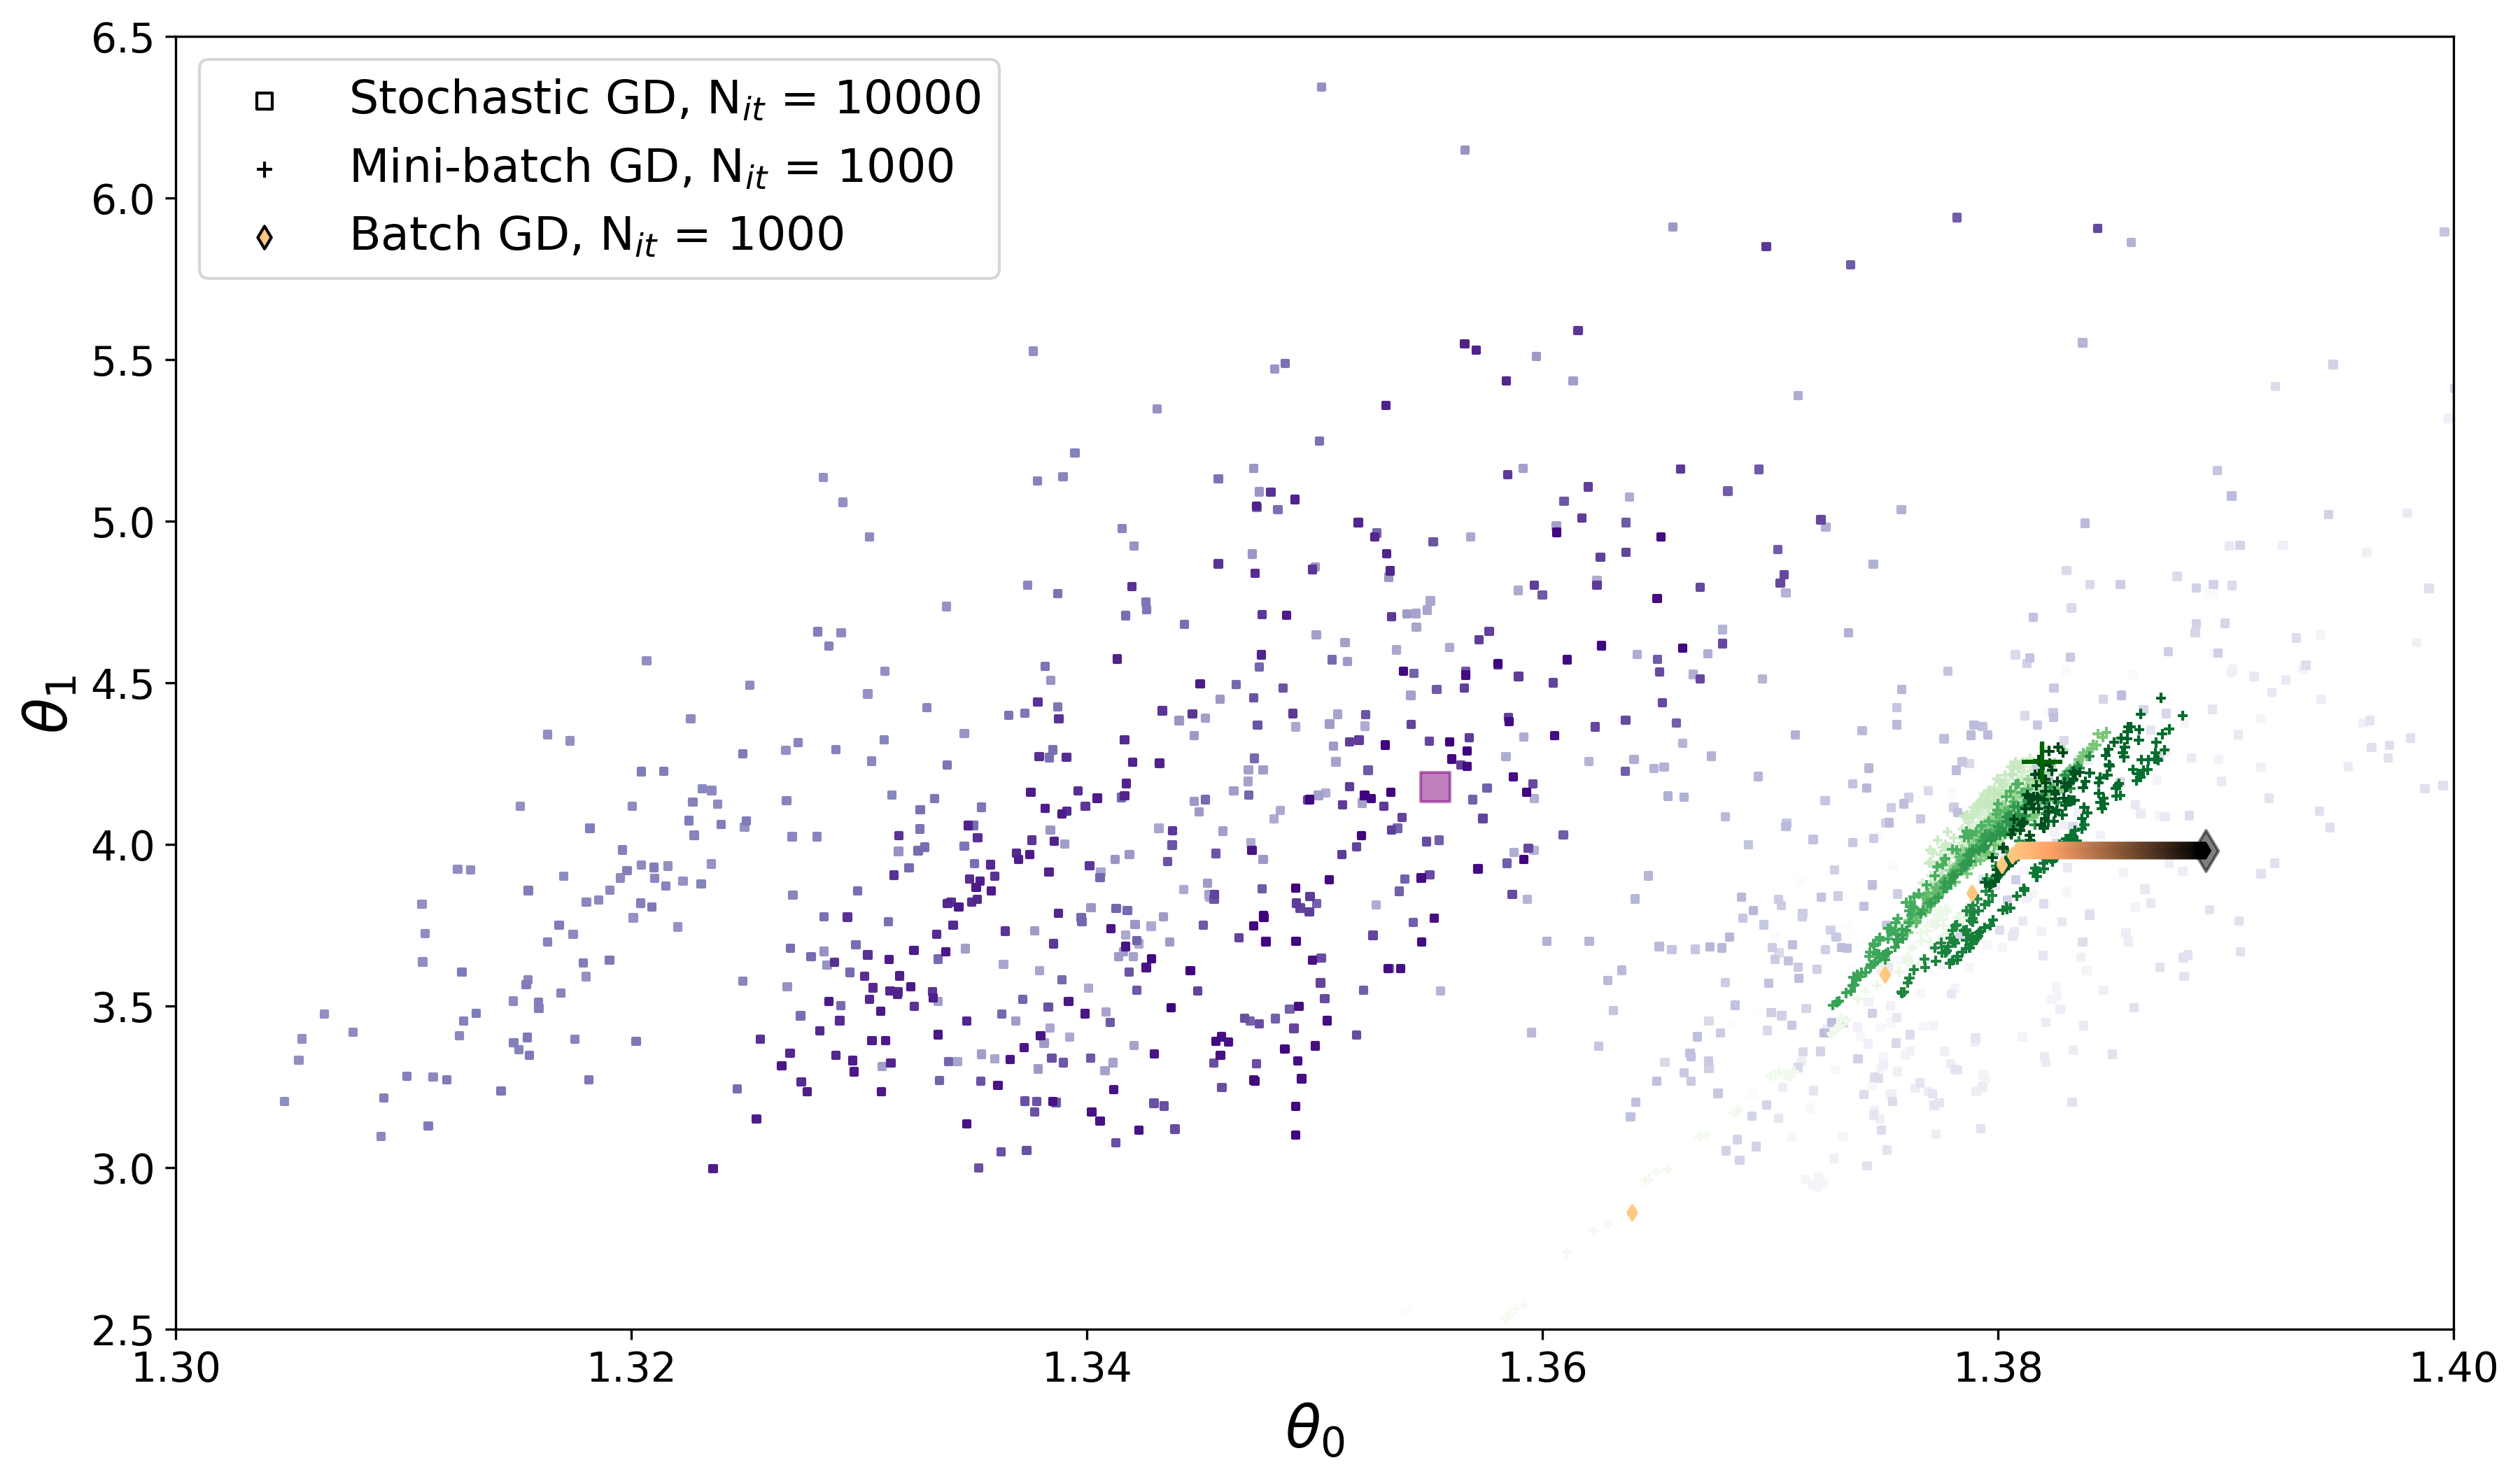

In [170]:
plt.figure(figsize=(14,8))

plt.scatter(theta_path_sgd[::10, 0].flatten(), theta_path_sgd[::10, 1].flatten(), marker = 's', s = 5, \
         label="Stochastic GD, N$_{it}$ = 10000", c = np.arange(1000), cmap=plt.cm.Purples)
plt.scatter(theta_path_mgd[:, 0].flatten(), theta_path_mgd[:, 1].flatten(), marker = "+", s = 12, linewidth=1, \
            label="Mini-batch GD, N$_{it}$ = 1000", c = np.arange(1000), cmap=plt.cm.Greens)
plt.scatter(theta_path_bgd[:, 0].flatten(), theta_path_bgd[:, 1].flatten(), marker = "d", s = 12, linewidth=1, \
            label="Batch GD, N$_{it}$ = 1000", c = np.arange(1000,0,-1), cmap=plt.cm.copper)

plt.scatter(theta_sgd[0],theta_sgd[1], marker = "s", s = 100, color = 'Purple', alpha = 0.5)
plt.scatter(theta_mgd[0],theta_mgd[1], marker = "+", s = 200, color = 'DarkGreen', alpha = 1)
plt.scatter(theta_bgd[0],theta_bgd[1], marker = "d", s = 100, color = 'k', alpha = 0.5)

legend = plt.legend(loc="upper left", fontsize=16)


for i in range(3):

    legend.legend_handles[i].set_color('k')
    legend.legend_handles[i]._sizes = [30]

plt.xlabel(r"$\theta_0$", fontsize=20)
plt.ylabel(r"$\theta_1$   ", fontsize=20)

plt.axis([1.3, 1.4, 2.5, 6.5])

#plt.savefig('AllThePaths.png', dpi = 300)
plt.show()


### Preguntas

1. Identifica en el código de mini batch GD dónde ocurre cada paso:

   - cálculo de las predicciones
   - cálculo del error o residuo
   - cálculo del gradiente
   - actualización de los parámetros

2. ¿Qué representan los parámetros $\theta_0$ y $\theta_1$ en este modelo?

3. Compara los parámetros encontrados por Gradient Descent con los obtenidos mediante `LinearRegression`. ¿Son iguales o parecidos? ¿Por qué no necesariamente coinciden exactamente?


4. Cambia el learning rate $\eta$. Prueba al menos tres valores: uno pequeño, uno razonable y uno demasiado grande. ¿Qué ocurre en cada caso?


5. Explica con tus palabras por qué la actualización tiene un signo menos: $\theta \leftarrow \theta - \eta \nabla L$

6. En la solución analítica derivamos e igualamos a cero. En Gradient Descent no resolvemos directamente la ecuación.  ¿Qué hacemos en cambio?

7. Compara Batch Gradient Descent, Stochastic Gradient Descent y Mini-batch Gradient Descent.

   - ¿Cuál usa todos los datos en cada actualización?
   - ¿Cuál actualiza los parámetros con más ruido?
   - ¿Cuál parece converger de forma más suave?

1. Los pasos del cálculo se dan de la siguiente manera en el código:

En este paso, también se encuentra el cálculo de predicciones:

`xi.dot(theta) - yi`

2. En este modelo $\theta_0$ representa el intercepto y $\theta_1$ la pendiente. Esto puede deducirse, principalmente, por sus valores (conocemos la relación real, y los parámetros son parecidos a los que entrega LinearRegression). Para corroborar visualmente véase el gráfico a continuación:

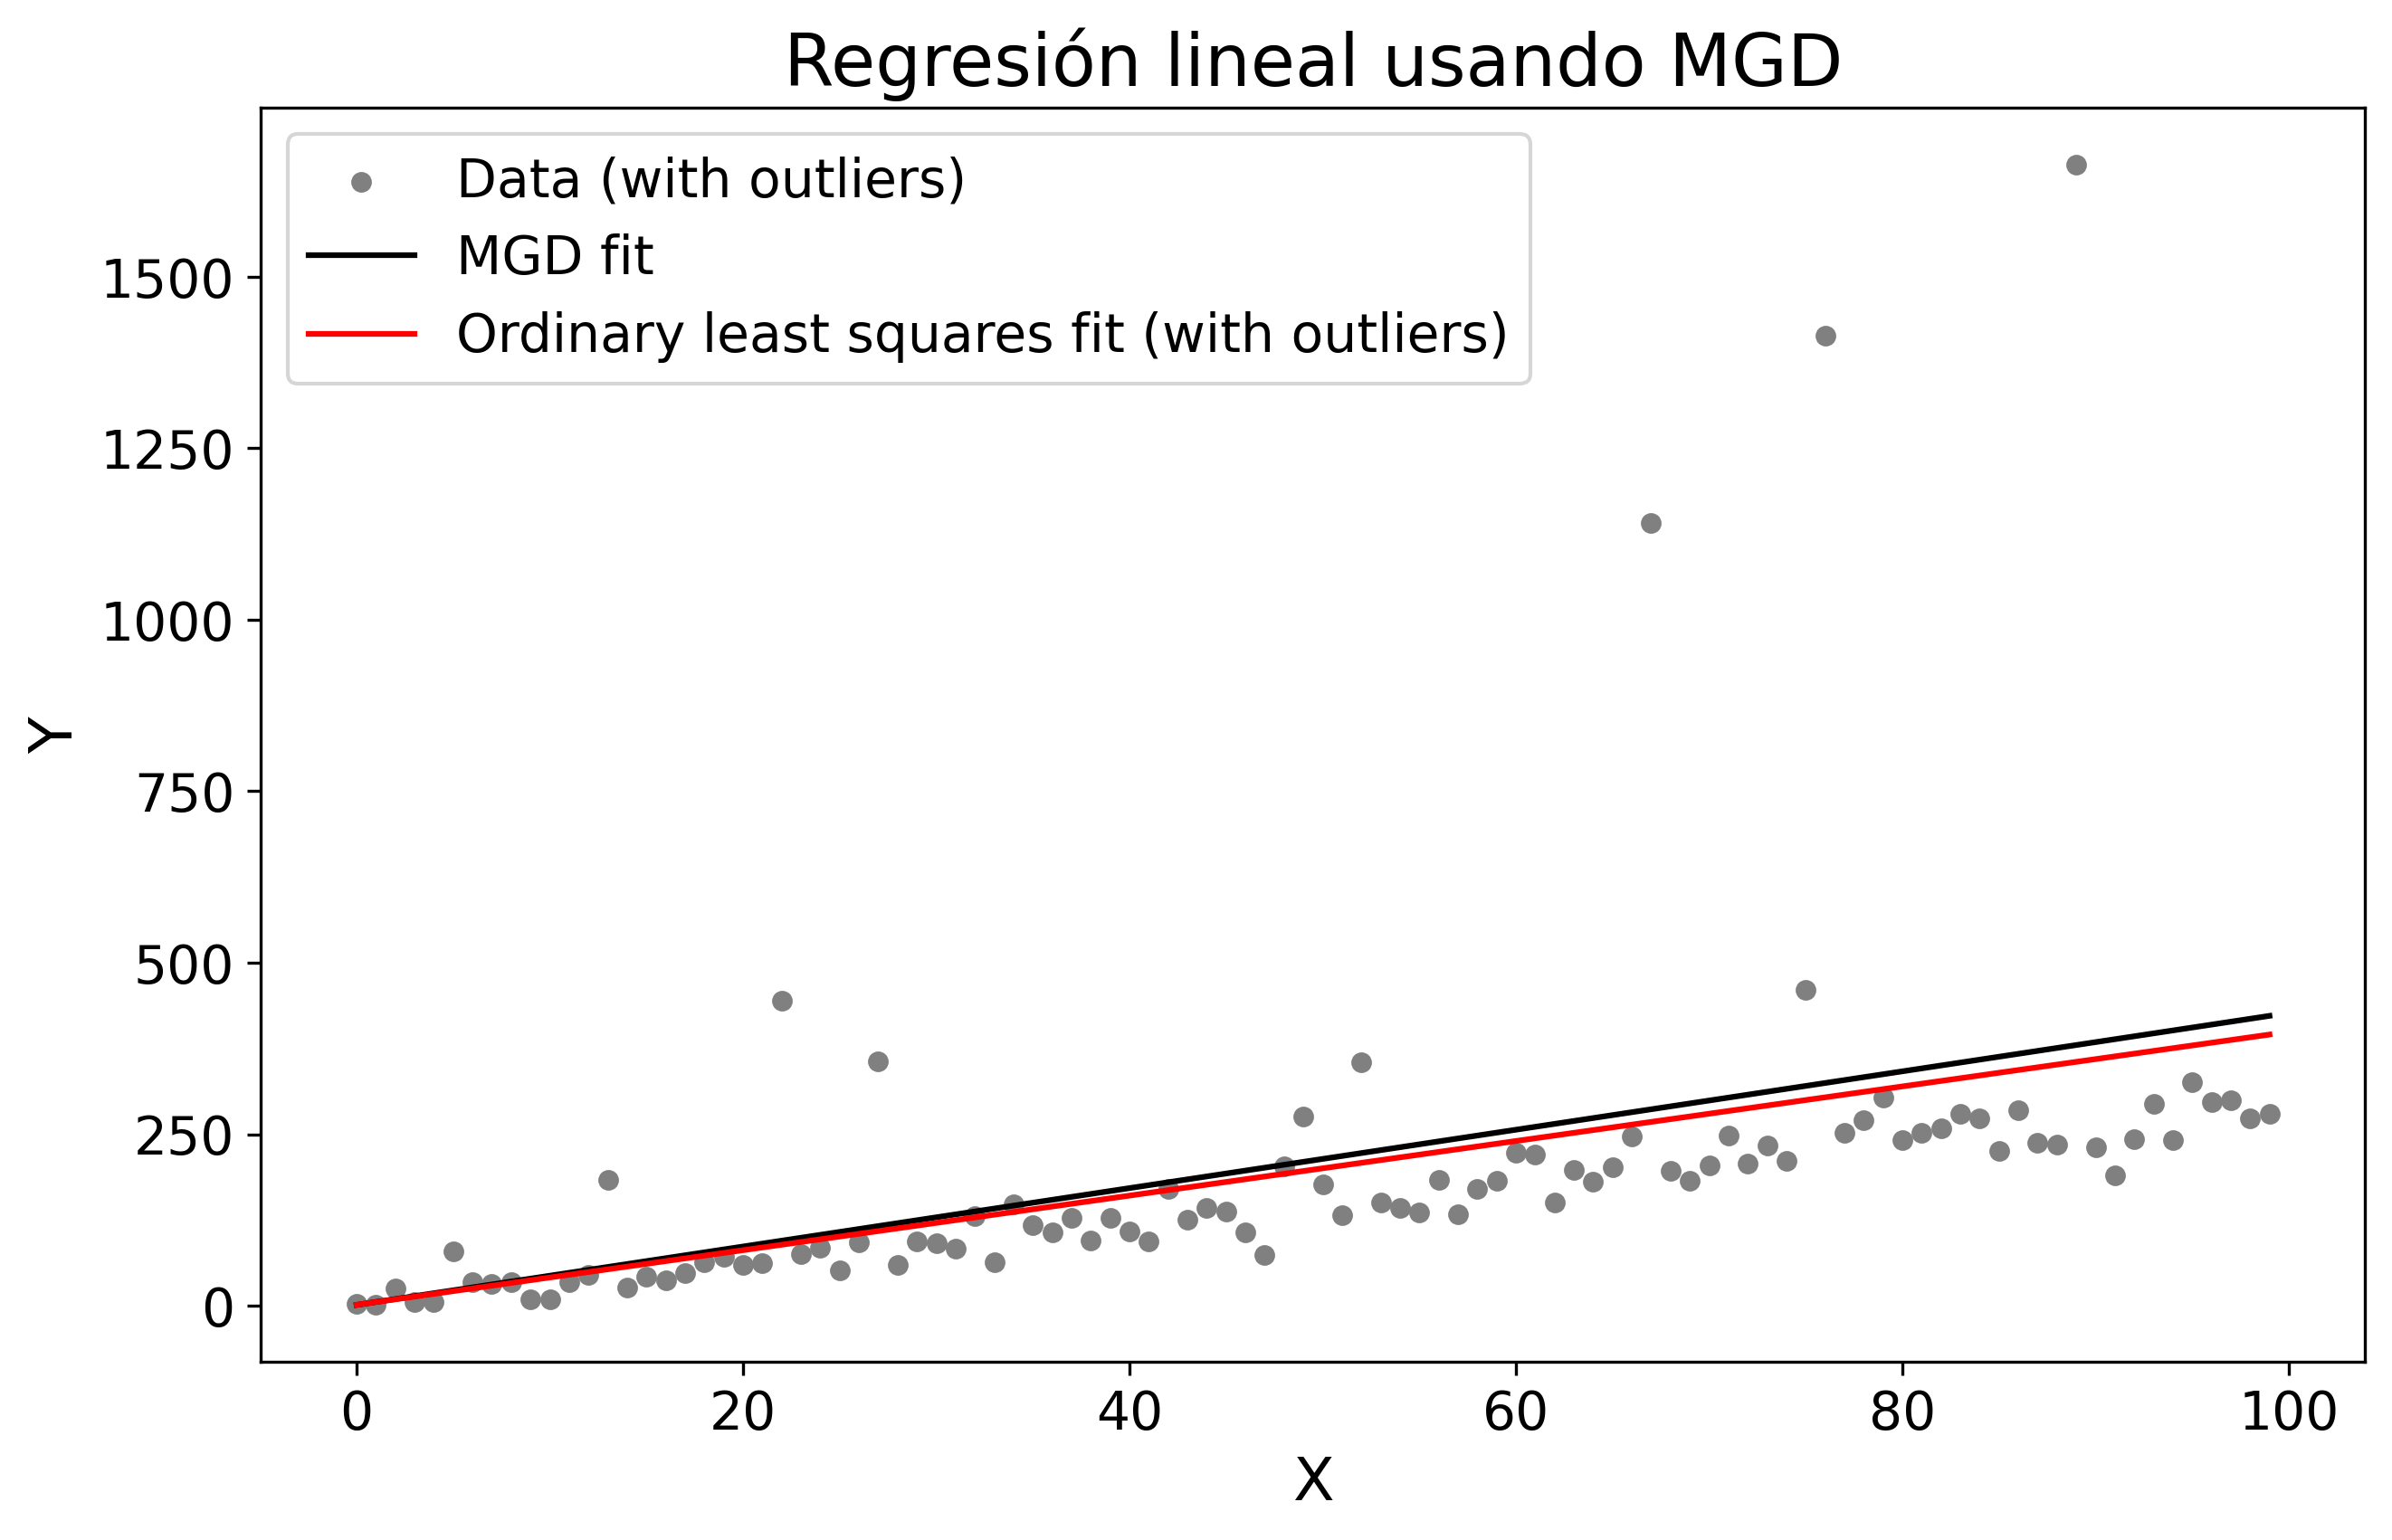

In [173]:
plt.figure(figsize = (10, 6))
plt.scatter(x,yp_wo, s = 20, c = 'gray', label = 'Data (with outliers)')
plt.plot(x, theta_mgd[1][0]*x + theta_mgd[0][0], c ='k', label = 'MGD fit')
plt.plot(x, slope_wo*x + intercept_wo, c ='red', label = 'Ordinary least squares fit (with outliers)')
plt.legend(fontsize = 14)
plt.xlabel('X')
plt.ylabel('Y')
plt.title("Regresión lineal usando MGD")
plt.show()

3. Tenemos, mediante GD: 1.382, 4.255 para el intercepto y la pendiente respectivamente. Mientras tanto, usando LinearRegression se obtuvo: 1.548 para el intercepto y 3.978 para la pendiente. Los valores resultantes para la pendiente son bastante similares entre métodos, mas no exactamente iguales. Es razonable que los resultados no coincidan exactamente al cambiar de método pues, valga la redundancia, se recurre a diferentes estrategias para lograr el objetivo de encontrar parámetros óptimos. LinearRegression trabaja con la solución analítica de mínimos cuadrados, mientras que GD utliliza gradientes para minimizar la pérdida.

4. A continuación, se muestra el script utilizado para experimentar con diferentes valores de $\eta$.

In [172]:
np.random.seed(10) # semilla inicial

eta_list = np.array([0.000001, 0.0001, 0.01]) #lista de valores de eta

theta_test = np.random.randn(2,1) # se comienza con valores aleatorios para theta

theta_path_mgd_test = []

minibatch_size = 10 

for e in eta_list: # iterando el mismo código anterior, pero para distintos valores de eta
    
    for epoch in range(n_iterations):
        
        shuffled_indices = np.random.permutation(m) 
        
        X_shuffled = X[shuffled_indices]
        
        y_shuffled = yp_wo.reshape(-1,1)[shuffled_indices]
        
        xi = X_shuffled[:minibatch_size] 
        
        yi = y_shuffled[:minibatch_size]
        
        gradients = 2/minibatch_size * xi.T.dot(xi.dot(theta_test) - yi)
        
        theta_test = theta_test - e * gradients
        
        theta_path_mgd_test.append(theta_test)
    
    #theta_path_mgd_test = np.array(theta_path_mgd_test)
    
    theta_mgd_test = theta_test 
    
    print(theta_mgd_test)
    print('-------------------------------------------')

[[1.38221508]
 [4.07579452]]
-------------------------------------------
[[1.34468945]
 [5.41542221]]
-------------------------------------------
[[nan]
 [nan]]
-------------------------------------------


/tmp/ipykernel_934246/3383578079.py:27: RuntimeWarning: invalid value encountered in subtract
  theta_test = theta_test - e * gradients


Puede verse que, a medida que se aumenta el valor del learning step, hay notables cambios en el parámetro de la pendiente (fundamental, pues determina la inclinación de la recta y por ende la naturaleza de la relación lineal entre los datos), que tiende a aumentar. El intercepto, mientras tanto, con un mayor $\eta$ parece disminuir. 
Interesantemente, cuando el learning step es muy grande (en este caso, 0.01) los valores calculados para los parámetros $\theta$ son indefinidos. A juzgar por los otros dos ejemplos y la tendencia de los parámetros a aumentar/disminuir, puede inferirse que nos encontramos con divergencias.

5. El cálculo tiene un signo negativo porque, matemáticamente, el gradiente represente la dirección de mayor crecimiento. Nosotros estamos buscando precisamente lo contrario; la dirección en la que el error decrece.

6. Al utilizar Gradient Descent, nos movemos por una "superficie" que representa la pérdida para distintos conjuntos de parámetros, y buscamos el punto en que la pérdida es mínima.

7. 
   - Como indican sus nombres, Batch y Mini batch utilizan subconjuntos de datos en cada actualización. El que usa todos los datos es Stocastic GD.
   - El método con más ruido y que abarca más puntos en la superficie es Mini Batch GD, que se mueve notablemente más que sus contrapartes.
   - A juzgar por el gráfico, el método que parece converger más suavemente es Batch GD. Mini batch es más ruidoso, y Stochastic GD converge de una manera más abrupta.
